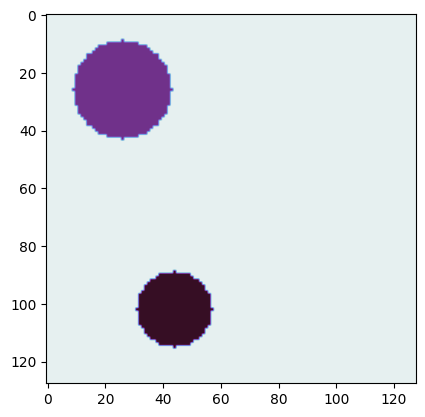

In [1]:
import torch
from transforms.radon import radon_transform as rt_torch
from scripts.transforms_jax.radon import radon_transform as rt_jax
import matplotlib.pyplot as plt
import cmocean as cmo


data = torch.load('data/circles-dataset-128.pt')
image = data['test'][0].squeeze(0).squeeze(0)  # (128, 128)
plt.imshow(image, cmap=cmo.cm.dense)

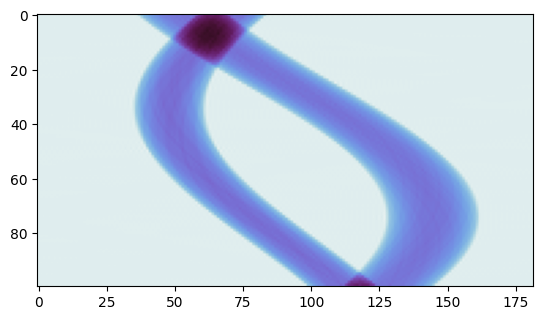

In [2]:
jax_radon = rt_jax(image.cpu().numpy(), N=100)
plt.imshow(jax_radon, cmap=cmo.cm.dense)

torch.Size([100, 182])


/home/johnma/d-flow/venv/lib64/python3.9/site-packages/networkx/utils/backends.py:135: RuntimeWarning: networkx backend defined more than once: nx-loopback
  backends.update(_get_backends("networkx.backends"))


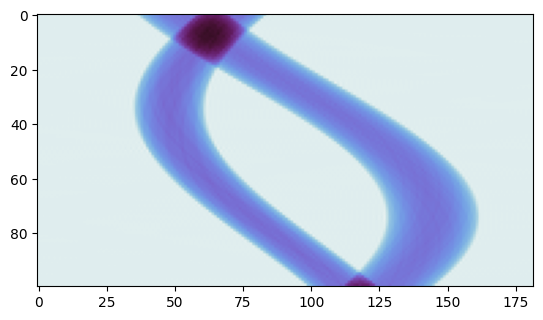

In [3]:
torch_radon = rt_torch(image, N=100)
print(torch_radon.shape)
plt.imshow(torch_radon.cpu().numpy(), cmap=cmo.cm.dense)

max error: 0.013809204
min error: -0.011461515
mean abs error: 6.277708e-05
mean rel error: 6.7904134e-06
mse: 8.7105455e-08
rmse: 0.00029513633


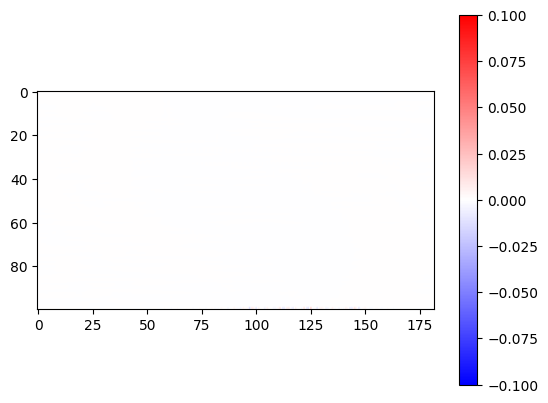

In [5]:
# calculate error
error = jax_radon - torch_radon.cpu().numpy()
plt.imshow(error, cmap='bwr', vmin=-0.1, vmax=0.1)
plt.colorbar()
print('max error:', error.max())
print('min error:', error.min())
print('mean abs error:', abs(error).mean())
import numpy as np
print('mean rel error:', abs(error).mean() / (abs(jax_radon).mean() + 1e-8))  # avoid div by zero
print('mse:', (error**2).mean())
print('rmse:', np.sqrt((error**2).mean()))